<a href="https://colab.research.google.com/github/varshamqa/AIML_Practice_Repo_VSC1/blob/main/Arima_Sarima_Varsha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import itertools
import statsmodels.api as sm
import matplotlib.pyplot as plt
import statsmodels.tsa.api as smt
import statsmodels.formula.api as smf

In [2]:
data = pd.read_csv("/content/Truck_sales.csv")

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Month-Year          144 non-null    object
 1   Number_Trucks_Sold  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [4]:
data.describe()

,Number_Trucks_Sold
count,144.000000
mean,428.729167
std,188.633037
min,152.000000
25%,273.500000
50%,406.000000
75%,560.250000
max,958.000000


In [5]:
data.head()

,Month-Year,Number_Trucks_Sold
0,03-Jan,155
1,03-Feb,173
2,03-Mar,204
3,03-Apr,219
4,03-May,223


In [6]:
data.tail()

,Month-Year,Number_Trucks_Sold
139,14-Aug,933
140,14-Sep,704
141,14-Oct,639
142,14-Nov,571
143,14-Dec,666


In [7]:
dates = pd.date_range(start='2002-01-01', freq = 'MS', periods= len(data))

In [8]:
import calendar
data['Month'] = dates.month
data['Month'] = data['Month'].apply(lambda x: calendar.month_abbr[x])
data['Year'] = dates.year

In [9]:
data.drop(['Month-Year'], axis=1, inplace=True)
data.rename(columns= {'Number_Trucks_Sold': 'Truck_Sales'}, inplace=True)
data = data[['Month','Year','Truck_Sales']]

In [10]:
data.set_index(dates, inplace = True)
data.head()

,Month,Year,Truck_Sales
2002-01-01,Jan,2002,155
2002-02-01,Feb,2002,173
2002-03-01,Mar,2002,204
2002-04-01,Apr,2002,219
2002-05-01,May,2002,223


# TODO: Linegraph demonstration Year vs Truck_Sales to analyze the sales over yesrs of time

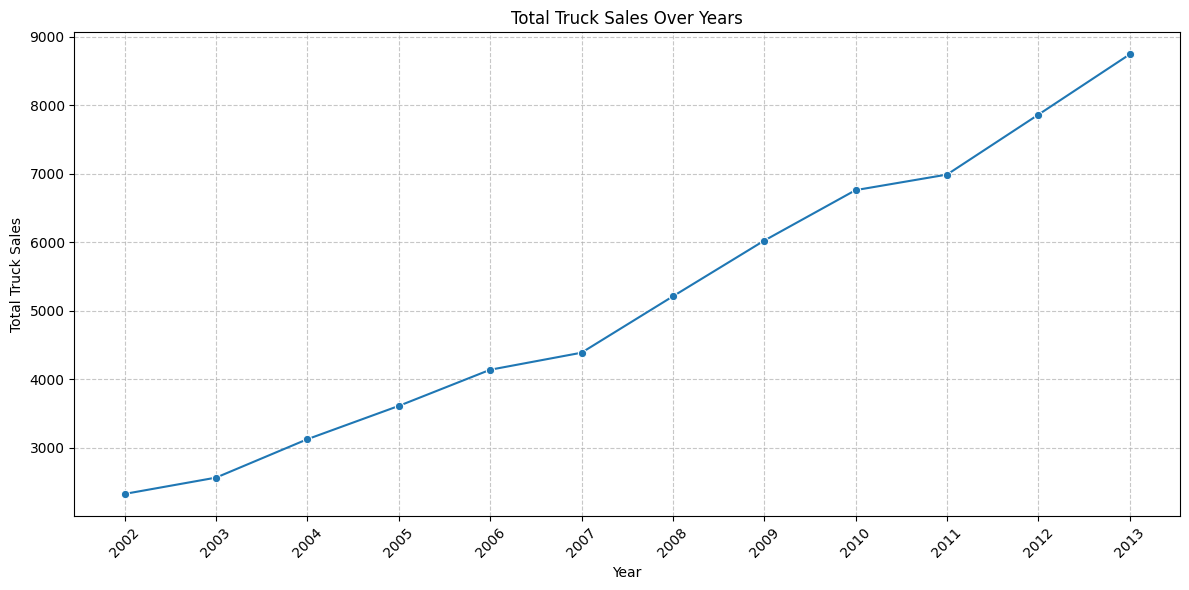

In [11]:
# Aggregate sales by year
yearly_sales = data.groupby('Year')['Truck_Sales'].sum().reset_index()

# Create the line plot
plt.figure(figsize=(12, 6))
sns.lineplot(x='Year', y='Truck_Sales', data=yearly_sales, marker='o')
plt.title('Total Truck Sales Over Years')
plt.xlabel('Year')
plt.ylabel('Total Truck Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(yearly_sales['Year'].unique(), rotation=45) # Ensure all years are shown and rotated for readability
plt.tight_layout()
plt.show()

In [12]:
from statsmodels.tsa.stattools import adfuller

In [13]:
sales_ts =data['Truck_Sales']
dftest = adfuller(sales_ts)
dftest

(np.float64(1.1158932574252673),
 np.float64(0.9953500083802601),
 14,
 129,
 {'1%': np.float64(-3.482087964046026),
  '5%': np.float64(-2.8842185101614626),
  '10%': np.float64(-2.578864381347275)},
 np.float64(1107.5217075915425))

In [14]:
print('DF test statistics is %3.3f' %dftest[0])
print('DF test p-value is %1.4f' %dftest[1])


DF test statistics is 1.116
DF test p-value is 0.9954


In [15]:
# Bivariate Analysis
ms_data = pd.pivot_table(data, values='Truck_Sales', index='Month', columns='Year')

In [16]:
ms_data

Year,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Month,,,,,,,,,,,,
Apr,219.0,229.0,276.0,307.0,398.0,385.0,455.0,530.0,590.0,590.0,671.0,781.0
Aug,228.0,262.0,307.0,373.0,419.0,451.0,535.0,624.0,719.0,778.0,861.0,933.0
Dec,182.0,216.0,255.0,299.0,309.0,353.0,428.0,471.0,517.0,519.0,624.0,666.0
Feb,173.0,185.0,220.0,263.0,287.0,275.0,341.0,405.0,440.0,465.0,501.0,572.0
Jan,155.0,160.0,201.0,237.0,272.0,283.0,336.0,394.0,437.0,471.0,499.0,578.0
Jul,228.0,262.0,307.0,354.0,407.0,465.0,561.0,636.0,716.0,756.0,844.0,958.0
Jun,208.0,230.0,274.0,336.0,374.0,407.0,485.0,576.0,650.0,670.0,727.0,824.0
Mar,204.0,217.0,274.0,297.0,363.0,362.0,411.0,488.0,548.0,558.0,625.0,646.0
May,223.0,231.0,318.0,338.0,424.0,432.0,499.0,587.0,656.0,671.0,777.0,872.0


In [17]:
# Arrange index in a monthly order of Jan-Dec
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
ms_data = ms_data.reindex(month_order)
display(ms_data.head(12))

Year,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
Month,,,,,,,,,,,,
Jan,155.0,160.0,201.0,237.0,272.0,283.0,336.0,394.0,437.0,471.0,499.0,578.0
Feb,173.0,185.0,220.0,263.0,287.0,275.0,341.0,405.0,440.0,465.0,501.0,572.0
Mar,204.0,217.0,274.0,297.0,363.0,362.0,411.0,488.0,548.0,558.0,625.0,646.0
Apr,219.0,229.0,276.0,307.0,398.0,385.0,455.0,530.0,590.0,590.0,671.0,781.0
May,223.0,231.0,318.0,338.0,424.0,432.0,499.0,587.0,656.0,671.0,777.0,872.0
Jun,208.0,230.0,274.0,336.0,374.0,407.0,485.0,576.0,650.0,670.0,727.0,824.0
Jul,228.0,262.0,307.0,354.0,407.0,465.0,561.0,636.0,716.0,756.0,844.0,958.0
Aug,228.0,262.0,307.0,373.0,419.0,451.0,535.0,624.0,719.0,778.0,861.0,933.0
Sep,188.0,219.0,255.0,289.0,329.0,359.0,432.0,492.0,560.0,560.0,641.0,704.0


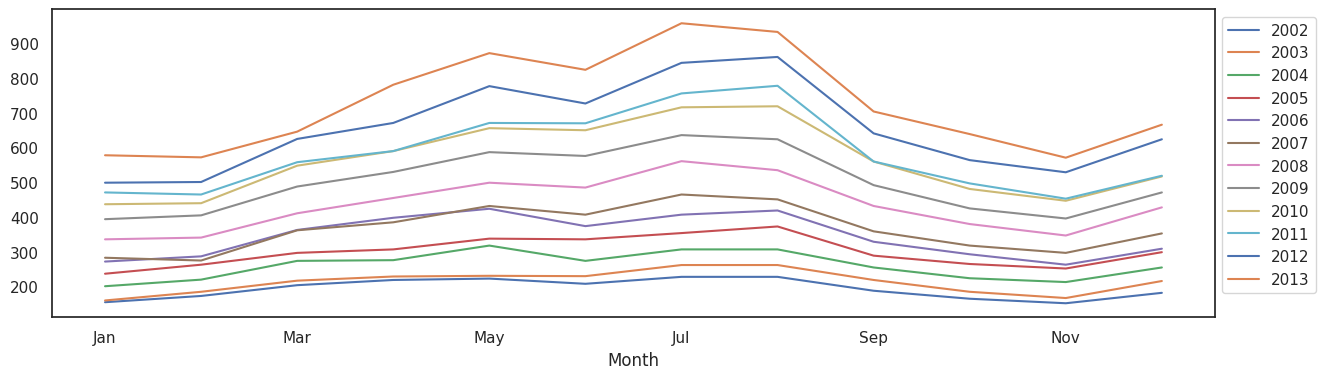

In [18]:
sns.set(style="white", rc={'figure.figsize':(15,4)})
ax = ms_data.plot()
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_facecolor('White')
plt.show()

In [19]:
ys_data = pd.pivot_table(data, values='Truck_Sales', index='Year', columns='Month')
ys_data= ys_data[['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']]

In [20]:
ys_data

Month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Year,,,,,,,,,,,,
2002,155.0,173.0,204.0,219.0,223.0,208.0,228.0,228.0,188.0,165.0,152.0,182.0
2003,160.0,185.0,217.0,229.0,231.0,230.0,262.0,262.0,219.0,185.0,167.0,216.0
2004,201.0,220.0,274.0,276.0,318.0,274.0,307.0,307.0,255.0,224.0,213.0,255.0
2005,237.0,263.0,297.0,307.0,338.0,336.0,354.0,373.0,289.0,265.0,252.0,299.0
2006,272.0,287.0,363.0,398.0,424.0,374.0,407.0,419.0,329.0,293.0,263.0,309.0
2007,283.0,275.0,362.0,385.0,432.0,407.0,465.0,451.0,359.0,318.0,297.0,353.0
2008,336.0,341.0,411.0,455.0,499.0,485.0,561.0,535.0,432.0,380.0,347.0,428.0
2009,394.0,405.0,488.0,530.0,587.0,576.0,636.0,624.0,492.0,425.0,396.0,471.0
2010,437.0,440.0,548.0,590.0,656.0,650.0,716.0,719.0,560.0,481.0,447.0,517.0


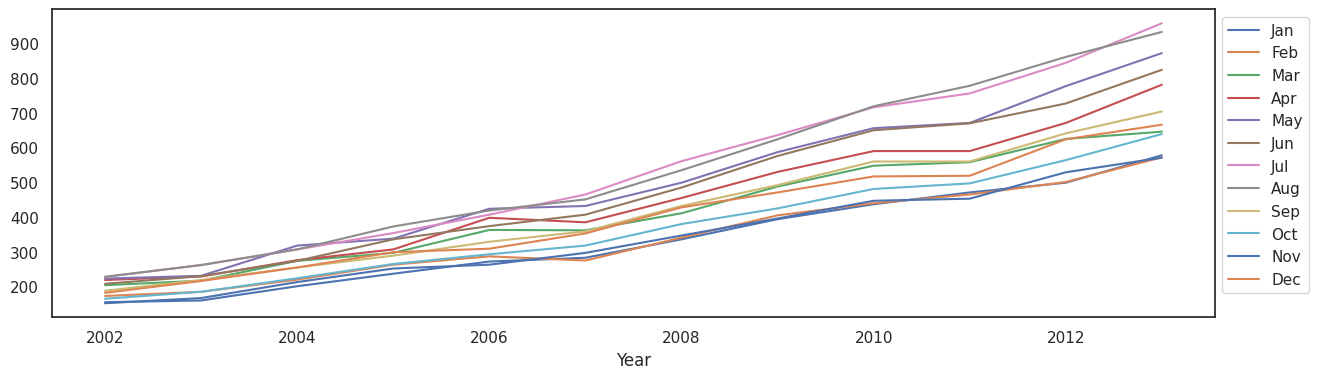

In [21]:
sns.set(style="white", rc={'figure.figsize':(15,4)})
ax = ys_data.plot()
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_facecolor('White')
plt.show()

In [22]:
sales_ts.index = dates
decomposition = sm.tsa.seasonal_decompose(sales_ts, model='multiplicative')


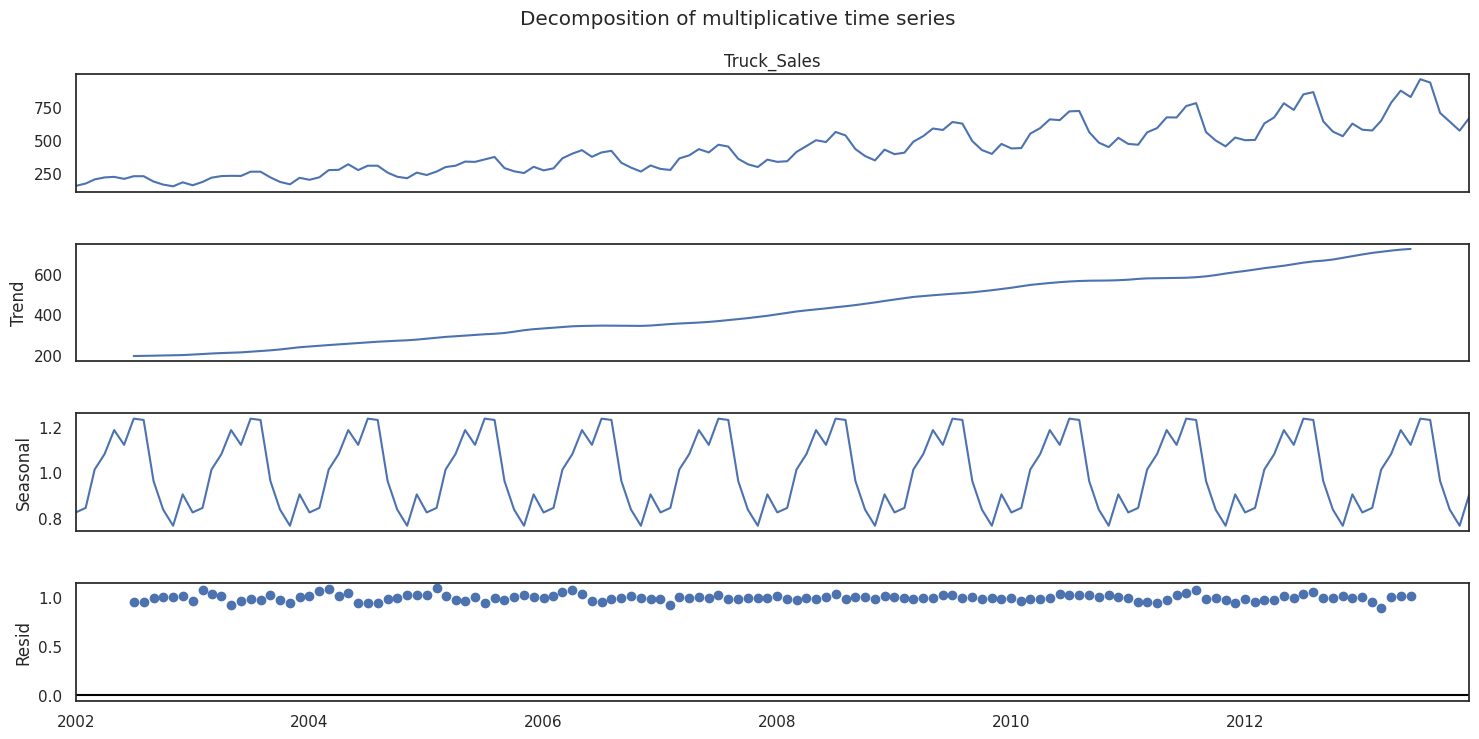

In [23]:
fig = decomposition.plot()
fig.set_figwidth(15)
fig.set_figheight(8)
fig.suptitle('Decomposition of multiplicative time series')
plt.show()

Text(0.5, 1.0, 'Truck Sales Time Series')

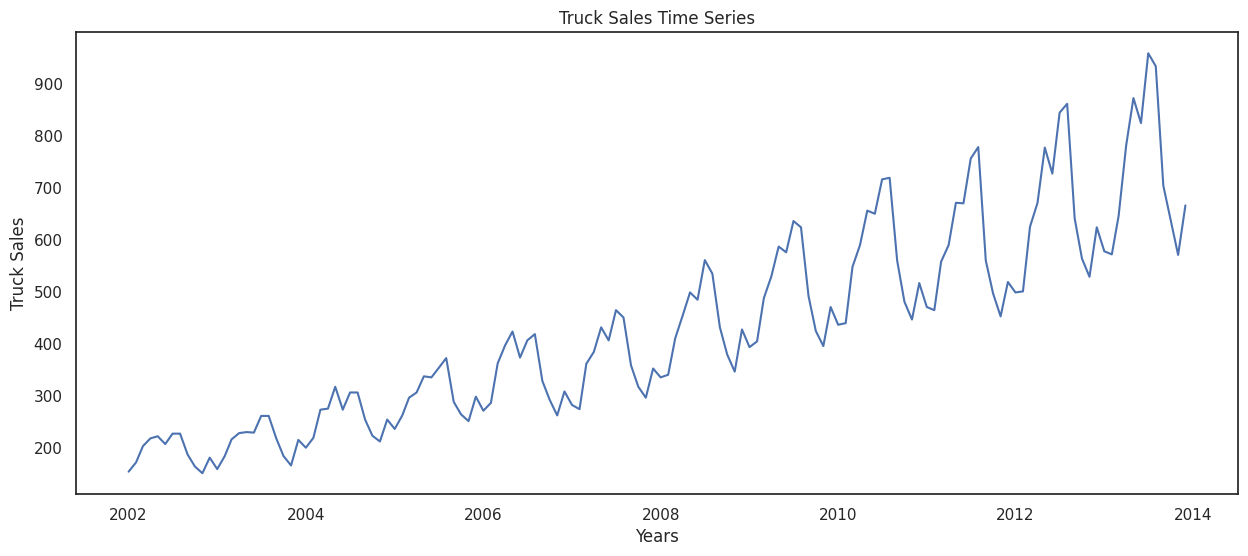

In [24]:
plt.figure(figsize=(15, 6))
plt.plot(sales_ts)
plt.xlabel('Years')
plt.ylabel('Truck Sales')
plt.title('Truck Sales Time Series')


Text(0, 0.5, 'Truck Sales')

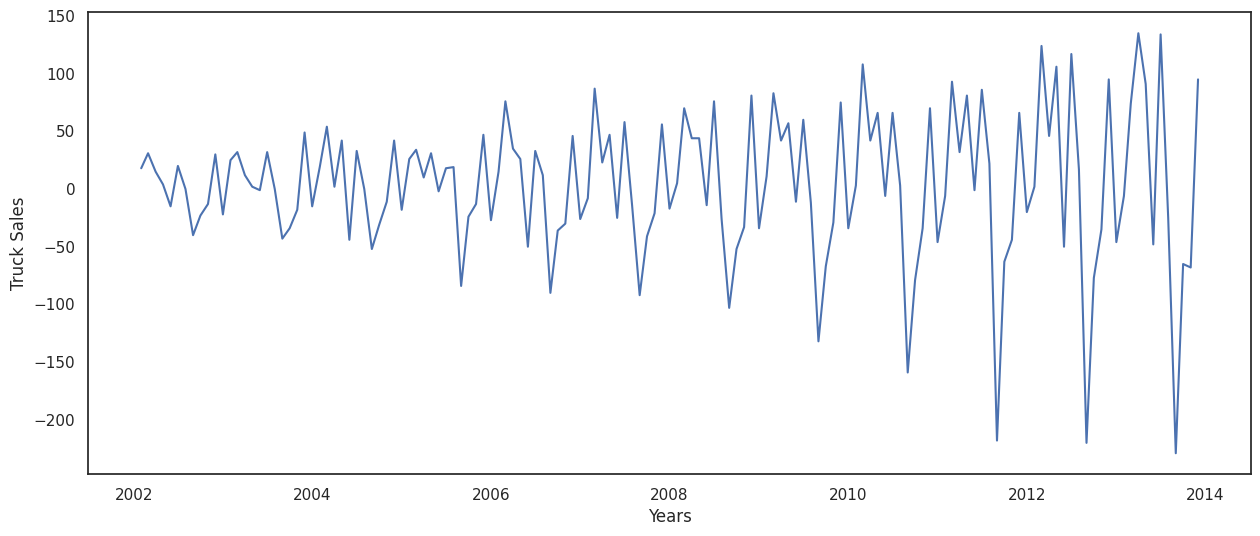

In [25]:
plt.figure(figsize=(15, 6))
plt.plot(sales_ts.diff(periods=1))
plt.xlabel('Years')
plt.ylabel('Truck Sales')


Text(0, 0.5, 'Truck Sales')

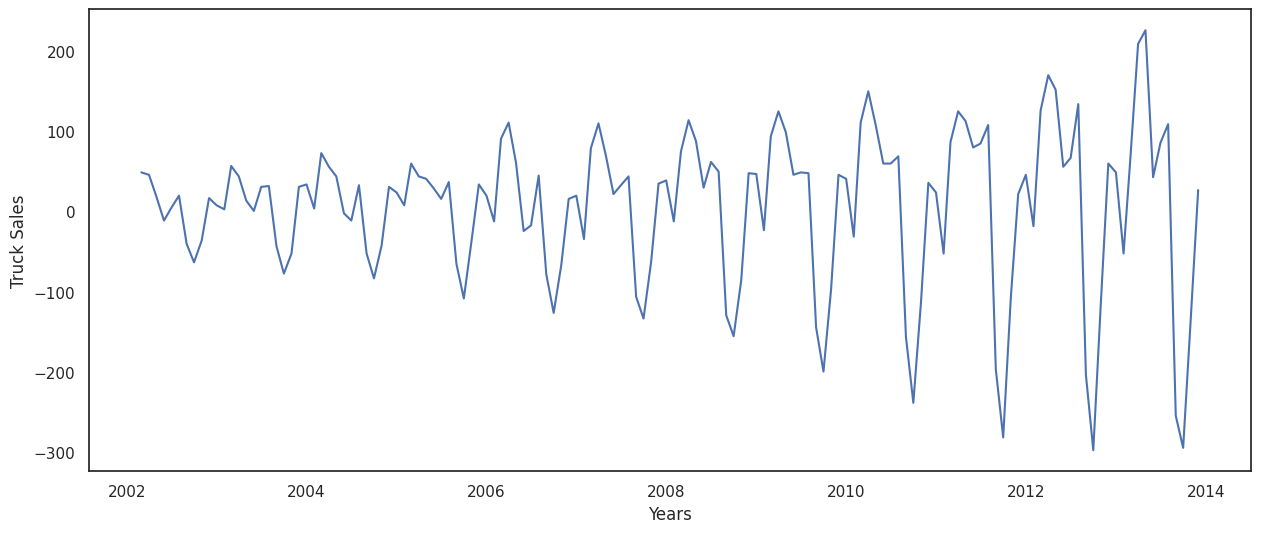

In [26]:
plt.figure(figsize=(15, 6))
plt.plot(sales_ts.diff(periods=2))
plt.xlabel('Years')
plt.ylabel('Truck Sales')

Text(0, 0.5, 'Truck Sales')

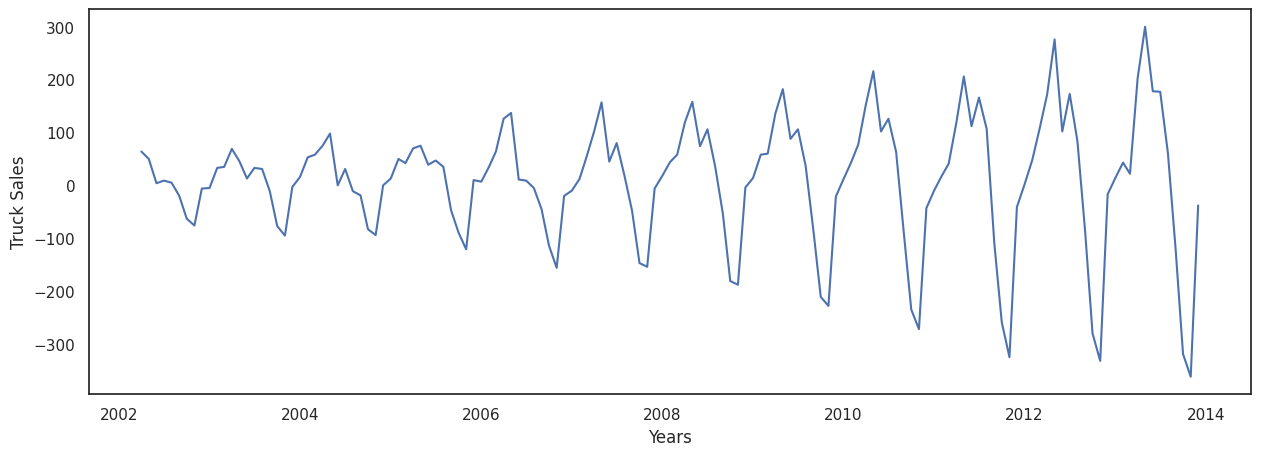

In [27]:
plt.figure(figsize=(15,5))
plt.plot(sales_ts.diff(periods=3))
plt.xlabel('Years')
plt.ylabel('Truck Sales')

In [28]:
p = range(1,4)

In [29]:
q = range(1,4)

In [30]:
d = range(0,2)

In [32]:
pdq_ar = list(itertools.product(p, range(1), range(1)))

pdq_arma = list(itertools.product(p, range(1), q))

pdq = list(itertools.product(p, d, q))

seasonal_pdq = [(x[0], x[1], x[2], 12) for x in list(itertools.product(p, d, q))]

In [34]:
pdq_ar

[(1, 0, 0), (2, 0, 0), (3, 0, 0)]

In [35]:
pdq_arma

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3)]

In [36]:
pdq

[(1, 0, 1),
 (1, 0, 2),
 (1, 0, 3),
 (1, 1, 1),
 (1, 1, 2),
 (1, 1, 3),
 (2, 0, 1),
 (2, 0, 2),
 (2, 0, 3),
 (2, 1, 1),
 (2, 1, 2),
 (2, 1, 3),
 (3, 0, 1),
 (3, 0, 2),
 (3, 0, 3),
 (3, 1, 1),
 (3, 1, 2),
 (3, 1, 3)]

In [37]:
data['date'] = data.index
train = data[data.index < '2013-01-01']
test = data[data.index >= '2013-01-01']

In [38]:
dftest = adfuller(train['Truck_Sales'])
dftest

print('DF test statistic is %3.3f' %dftest[0])
print('DF test p-value is %1.4f' %dftest[1])

DF test statistic is 0.984
DF test p-value is 0.9941


In [39]:
train_sales_ts_log = np.log10(train['Truck_Sales'])

best_aic = np.inf
best_pdq = None
best_seasonal_pdq = None
temp_model = None

In [40]:
from statsmodels.tsa.arima.model import ARIMA

AR_AIC = pd.DataFrame(columns = ['param', 'AIC'])

for param in pdq_ar:
  ARIMA_model = ARIMA(train_sales_ts_log, order = param).fit()
  print('ARIMA{} - AIC:{}'.format(param, ARIMA_model.aic))
  row = {'param':param, 'AIC':ARIMA_model.aic}
  AR_AIC = pd.concat([AR_AIC, pd.DataFrame([row])], ignore_index = True)

ARIMA(1, 0, 0) - AIC:-378.22971268983827


/tmp/ipykernel_722/335702300.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  AR_AIC = pd.concat([AR_AIC, pd.DataFrame([row])], ignore_index = True)


ARIMA(2, 0, 0) - AIC:-379.0995565821006
ARIMA(3, 0, 0) - AIC:-377.1147176105346


In [41]:
best_model = ARIMA(train_sales_ts_log, order = (2, 0, 0))
best_results = best_model.fit()

In [42]:
print(best_results.summary().tables[0])
print(best_results.summary().tables[1])


                               SARIMAX Results                                
Dep. Variable:            Truck_Sales   No. Observations:                  132
Model:                 ARIMA(2, 0, 0)   Log Likelihood                 193.550
Date:                Thu, 16 Jul 2026   AIC                           -379.100
Time:                        15:11:36   BIC                           -367.568
Sample:                    01-01-2002   HQIC                          -374.414
                         - 12-01-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.5497      0.087     29.359      0.000       2.379       2.720
ar.L1          1.1061      0.124      8.914      0.000       0.863       1.349
ar.L2         -0.1491      0.124     -1.205      0.2

In [43]:
pred_dynamic = best_results.get_prediction(start = pd.to_datetime('2012-01-01'), dynamic = True, full_results = True)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['full_results']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [44]:
pred99 = best_results.get_forecast(steps=len(test), alpha = 0.1)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['alpha']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [45]:
sales_ts_forecasted = pred_dynamic.predicted_mean
testCopy1 = test.copy()
testCopy1['sales_ts_forecasted'] = np.power(10, pred99.predicted_mean)

In [46]:
MSE = ((testCopy1['Truck_Sales'] - testCopy1['sales_ts_forecasted']) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(MSE, 3)))
RMSE = np.sqrt(MSE)
print('The Root Mean Squared Error of our forecasts is {}'.format(round(RMSE, 3)))

The Mean Squared Error of our forecasts is 54027.779
The Root Mean Squared Error of our forecasts is 232.439


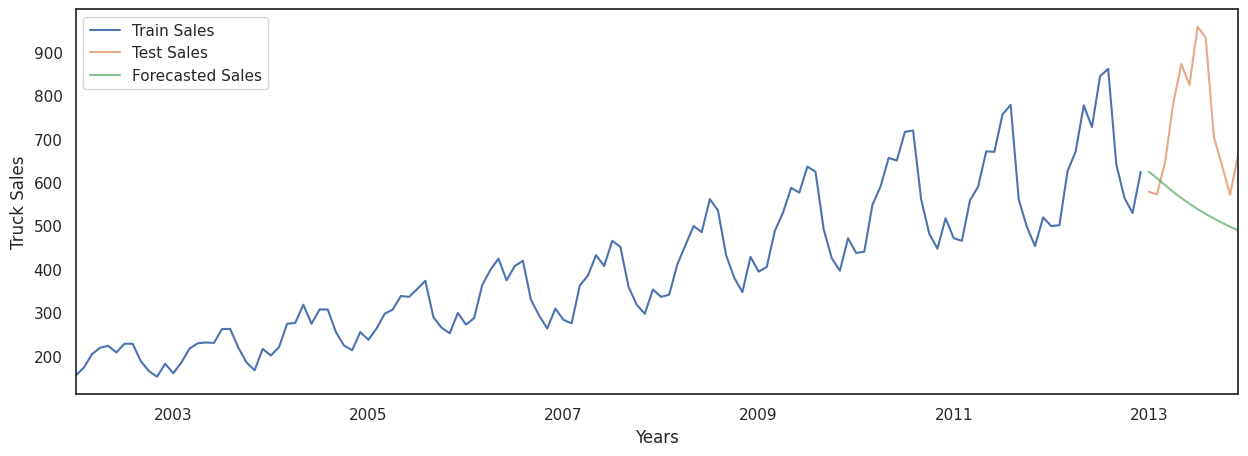

In [47]:
axis = train['Truck_Sales'].plot(label='Train Sales', figsize=(15, 5))
testCopy1['Truck_Sales'].plot(ax=axis, label='Test Sales', alpha=0.7)
testCopy1['sales_ts_forecasted'].plot(ax=axis, label='Forecasted Sales', alpha=0.7)
axis.set_xlabel('Years')
axis.set_ylabel('Truck Sales')
plt.legend(loc='best')
plt.show()
plt.close()

In [131]:
data_filled = {'Truck_Sales': np.random.rand(100)*10+20}

In [132]:
data_filled= pd.DataFrame(data_filled, index=pd.date_range(start='2003-01-01',periods=100, freq='ME'))

In [133]:
result= adfuller(data_filled['Truck_Sales'])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
	print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.579100
p-value: 0.000000
Critical Values:
	1%: -3.498
	5%: -2.891
	10%: -2.583


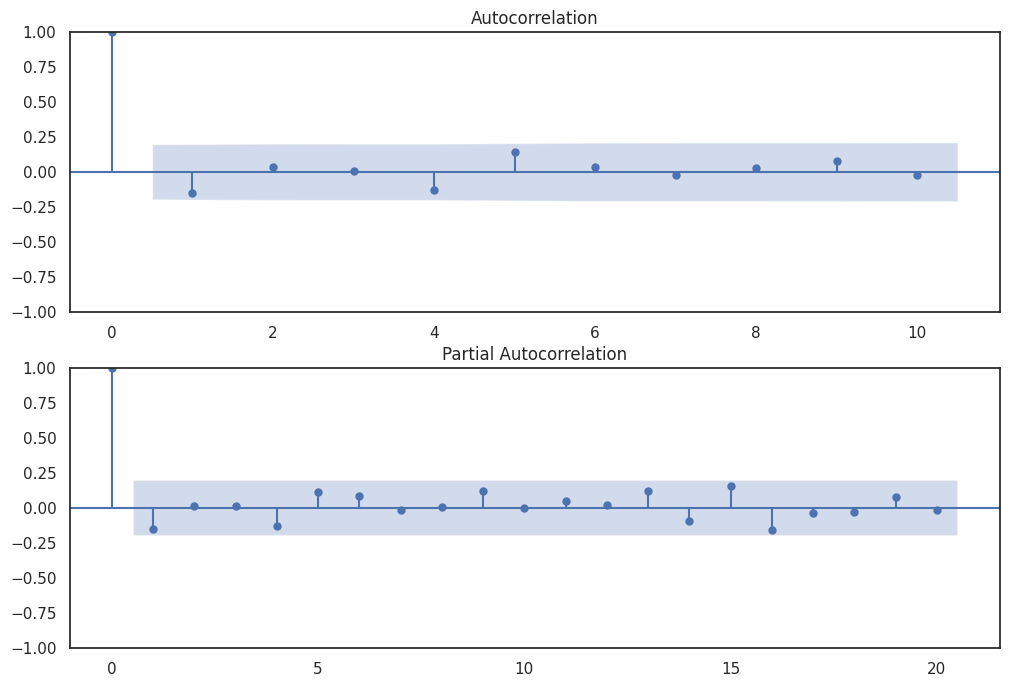

In [134]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2)= plt.subplots(2, 1, figsize=(12,8))
plot_acf(data_filled['Truck_Sales'], lags=10, ax=ax1)
plot_pacf(data_filled['Truck_Sales'], lags=20,ax=ax2)
plt.show()

In [135]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

order =(1,1,1)
seasonal_order = (1,1,1,12)
model = SARIMAX(data_filled['Truck_Sales'], order=order, seasonal_order=seasonal_order)
result= model.fit()
print(result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                        Truck_Sales   No. Observations:                  100
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -230.475
Date:                            Thu, 16 Jul 2026   AIC                            470.951
Time:                                    16:50:01   BIC                            483.280
Sample:                                01-31-2003   HQIC                           475.915
                                     - 04-30-2011                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1872      0.119     -1.580      0.114      -0.420       0.045
ma.L1         -0.9526      0.068   

In [136]:
forcast_step=100
forcast = result.get_forecast(steps=forcast_step)
forcast_index=pd.date_range(start=data_filled.index[-1]+ pd.DateOffset(month=1),periods=forcast_step,freq='ME')

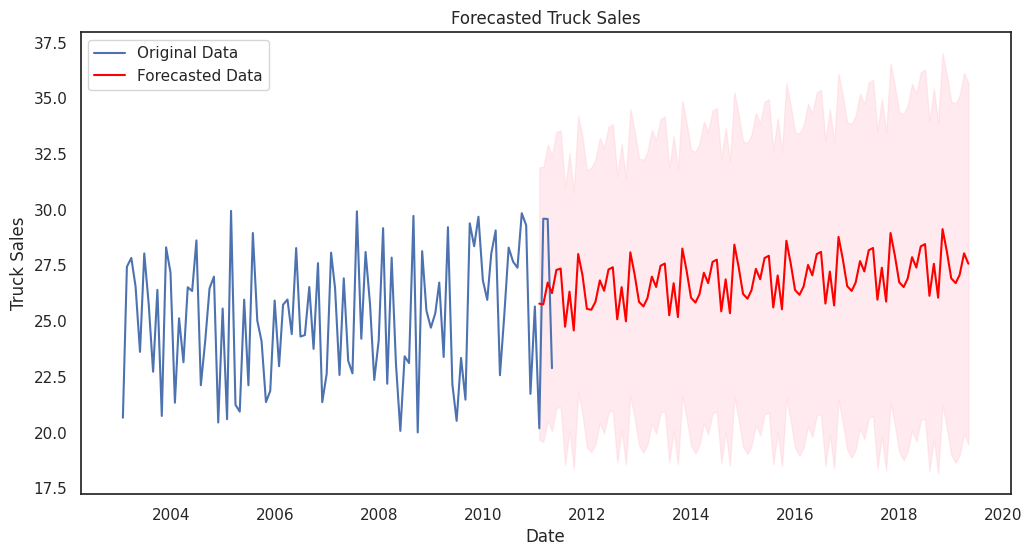

In [137]:
plt.figure(figsize=(12,6))
plt.plot(data_filled['Truck_Sales'], label='Original Data')
plt.plot(forcast_index, forcast.predicted_mean, color='red', label='Forecasted Data')
conf_int_df = forcast.conf_int()
plt.fill_between(forcast_index, conf_int_df.iloc[:,0], conf_int_df.iloc[:,1], color='pink', alpha=0.3)
plt.title('Forecasted Truck Sales')
plt.xlabel('Date')
plt.ylabel('Truck Sales')
plt.legend()
plt.show()

In [138]:
forcast_predicted_mean = forcast.predicted_mean
forcast_predicted_mean.index = forcast_index

In [139]:
forcast_predicted_mean.shape

(100,)

In [140]:
data_filled['Truck_Sales'].shape

(100,)

In [141]:
mse= ((data_filled['Truck_Sales'] - forcast.predicted_mean) ** 2).mean()
print('The Mean Squared Error of our forecasts is {}'.format(round(mse, 3)))

The Mean Squared Error of our forecasts is nan
